# Bank Customer Churn Prediction

This project predicts whether a bank customer will churn (`Exited = 1`) using supervised machine learning and explains the full end-to-end workflow.

## 2. Problem Statement

Banks lose significant revenue when customers leave. This notebook solves a **binary classification** problem: predicting churn risk early enough to support retention actions.

This is relevant because churn prediction helps teams prioritize outreach, reduce customer loss, and improve long-term profitability.

## 3. Dataset / Data Source

- **Source:** Kaggle dataset `kartiksaini18/churn-bank-customer`
- **File used:** `Churn_Modelling.csv`
- **Target:** `Exited` (0 = stayed, 1 = churned)

### Key features
- Customer profile: `Age`, `Gender`, `Geography`, `CreditScore`
- Relationship/account: `Tenure`, `Balance`, `NumOfProducts`, `HasCrCard`, `IsActiveMember`
- Financial: `EstimatedSalary`

Identifier fields (`RowNumber`, `CustomerId`, `Surname`) are removed during preprocessing because they are not useful predictive signals.

## 4. Import Libraries

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

Matplotlib is building the font cache; this may take a moment.


**Library roles:**
- `pandas` and `numpy` for data operations
- `seaborn` and `matplotlib` for EDA and diagnostics
- `scikit-learn` for splitting, preprocessing, modeling, and evaluation

## 5. Data Loading

In [2]:
def resolve_dataset_csv() -> Path:
    # Prefer local kagglehub cache to keep notebook runnable offline after first download
    cache_root = Path.home() / '.cache' / 'kagglehub' / 'datasets' / 'kartiksaini18' / 'churn-bank-customer' / 'versions'
    if cache_root.exists():
        cached_files = sorted(cache_root.glob('*/Churn_Modelling.csv'))
        if cached_files:
            return cached_files[-1]

    # Fallback: download from Kaggle if cache is missing
    import kagglehub
    dataset_dir = Path(kagglehub.dataset_download('kartiksaini18/churn-bank-customer'))
    return dataset_dir / 'Churn_Modelling.csv'


csv_path = resolve_dataset_csv()
df_raw = pd.read_csv(csv_path)

print(f'Dataset path: {csv_path}')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Dataset path: /Users/lucaspeterson/.cache/kagglehub/datasets/kartiksaini18/churn-bank-customer/versions/1/Churn_Modelling.csv
Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


The code loads the data from local cache when available; otherwise it downloads the dataset once via `kagglehub`.

## 6. Data Exploration (EDA)

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [4]:
# Missing values
missing_summary = df_raw.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

Series([], dtype: int64)

In [5]:
# Statistical overview
df_raw.describe(include='all').transpose().head(15)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


Overall churn rate: 20.37%


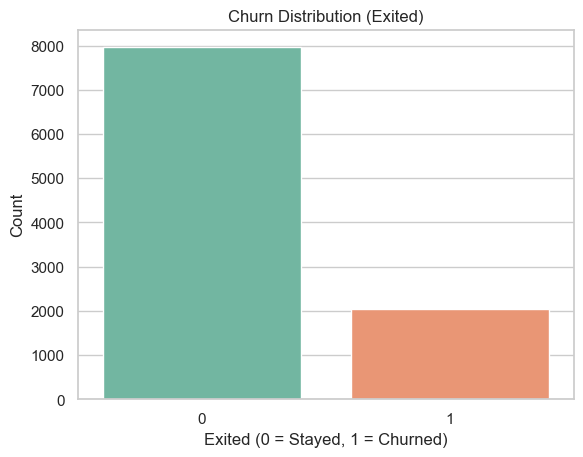

In [6]:
# Churn class distribution
churn_rate = df_raw['Exited'].mean()
print(f'Overall churn rate: {churn_rate:.2%}')

ax = sns.countplot(data=df_raw, x='Exited', palette='Set2')
ax.set_title('Churn Distribution (Exited)')
ax.set_xlabel('Exited (0 = Stayed, 1 = Churned)')
ax.set_ylabel('Count')
plt.show()

### EDA observations
- The target is imbalanced (fewer churners than non-churners).
- Data quality is generally clean (few or no missing values).
- Variables such as `Age`, `IsActiveMember`, and `NumOfProducts` are often informative for churn behavior.

## 7. Data Preprocessing

In [7]:
df = df_raw.copy()

# Remove ID-like columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Encode categorical variables
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

X = df.drop(columns=['Exited'])
y = df['Exited']

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)
X.head()

Feature matrix shape: (10000, 11)
Target vector shape: (10000,)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True


In [8]:
# Split before scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale inputs for Logistic Regression
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

print('Train samples:', len(X_train))
print('Test samples:', len(X_test))

Train samples: 8000
Test samples: 2000


## 8. Model Building

We use two complementary models:
- **Logistic Regression**: interpretable linear baseline with `class_weight='balanced'`
- **Gradient Boosting**: ensemble model that captures non-linear patterns

In [9]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

print('Both models trained successfully.')

Both models trained successfully.


## 9. Model Evaluation

In [10]:
# Predictions and probabilities
lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

gb_pred = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]

metrics_df = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_score(y_test, lr_pred),
        'Precision': precision_score(y_test, lr_pred),
        'Recall': recall_score(y_test, lr_pred),
        'F1': f1_score(y_test, lr_pred),
        'ROC AUC': roc_auc_score(y_test, lr_proba),
    },
    {
        'Model': 'Gradient Boosting',
        'Accuracy': accuracy_score(y_test, gb_pred),
        'Precision': precision_score(y_test, gb_pred),
        'Recall': recall_score(y_test, gb_pred),
        'F1': f1_score(y_test, gb_pred),
        'ROC AUC': roc_auc_score(y_test, gb_proba),
    },
]).sort_values('ROC AUC', ascending=False)

metrics_df

,Model,Accuracy,Precision,Recall,F1,ROC AUC
1,Gradient Boosting,0.8700,0.792829,0.488943,0.604863,0.870831
0,Logistic Regression,0.7135,0.387228,0.700246,0.498688,0.777138


In [11]:
print('Logistic Regression - Confusion Matrix')
print(confusion_matrix(y_test, lr_pred))
print('\nLogistic Regression - Classification Report')
print(classification_report(y_test, lr_pred))

print('Gradient Boosting - Confusion Matrix')
print(confusion_matrix(y_test, gb_pred))
print('\nGradient Boosting - Classification Report')
print(classification_report(y_test, gb_pred))

Logistic Regression - Confusion Matrix
[[1142  451]
 [ 122  285]]

Logistic Regression - Classification Report
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

Gradient Boosting - Confusion Matrix
[[1541   52]
 [ 208  199]]

Gradient Boosting - Classification Report
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



**Metric interpretation:**
- `Precision`: quality of positive (churn) predictions
- `Recall`: how many true churners are captured
- `ROC AUC`: threshold-independent ranking quality

## 10. Visualization

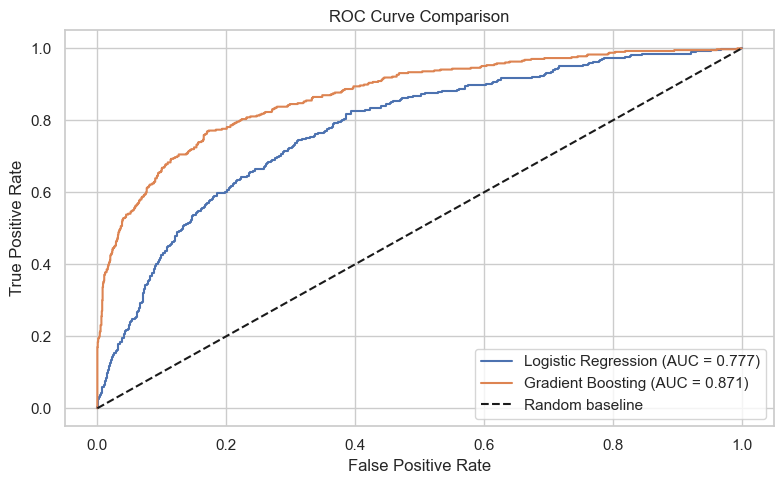

In [12]:
# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_proba):.3f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, gb_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

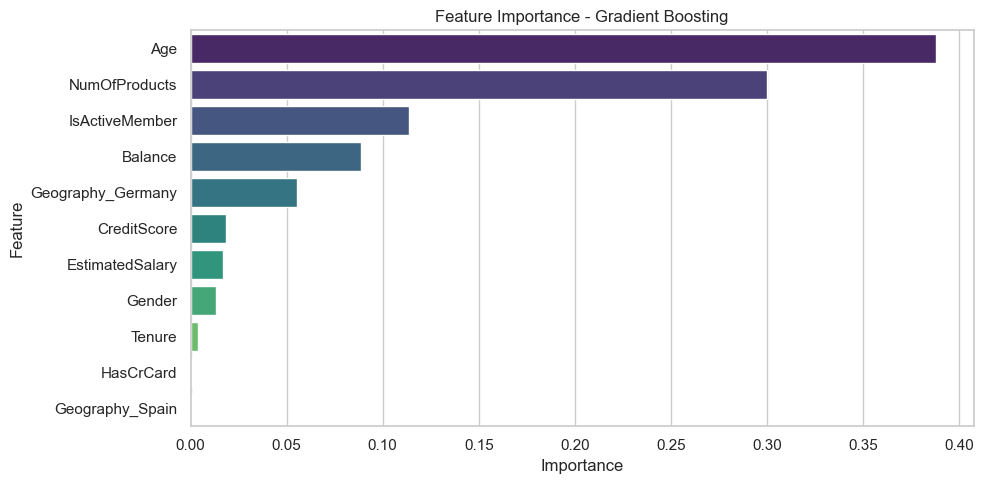

Age                  0.388266
NumOfProducts        0.299886
IsActiveMember       0.113911
Balance              0.088915
Geography_Germany    0.055604
CreditScore          0.018675
EstimatedSalary      0.016668
Gender               0.013160
Tenure               0.003767
HasCrCard            0.000665
dtype: float64

In [13]:
# Feature importance (Gradient Boosting)
importances = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance - Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

importances.head(10)

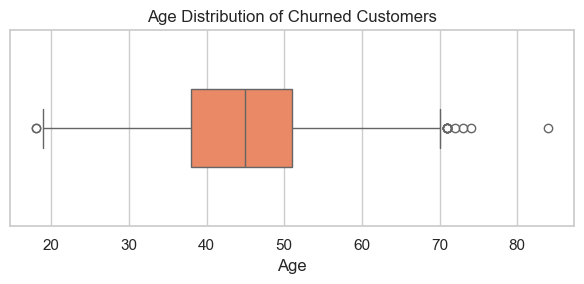

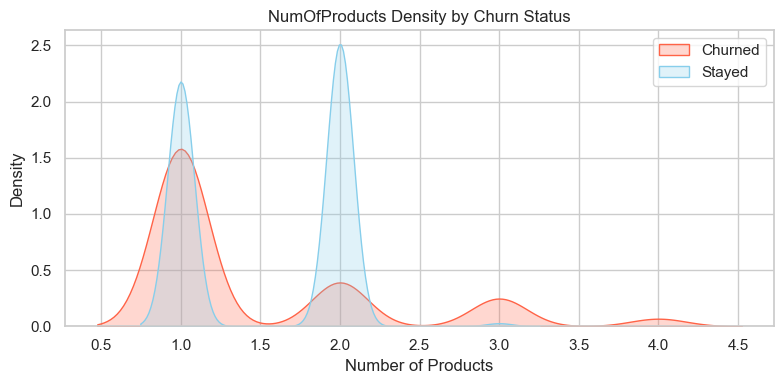

In [14]:
# EDA visuals from original script
plt.figure(figsize=(6, 3))
sns.boxplot(data=df_raw[df_raw['Exited'] == 1], x='Age', color='coral', width=0.4)
plt.title('Age Distribution of Churned Customers')
plt.xlabel('Age')
plt.yticks([])
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_raw[df_raw['Exited'] == 1], x='NumOfProducts', label='Churned', fill=True, color='tomato')
sns.kdeplot(data=df_raw[df_raw['Exited'] == 0], x='NumOfProducts', label='Stayed', fill=True, color='skyblue')
plt.title('NumOfProducts Density by Churn Status')
plt.xlabel('Number of Products')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Prediction / Inference

In [15]:
# Example inference on one test sample
sample_idx = X_test.index[0]
sample_raw = X_test.loc[[sample_idx]]
sample_scaled = X_test_scaled.loc[[sample_idx]]

lr_sample_prob = lr.predict_proba(sample_scaled)[0, 1]
gb_sample_prob = gb.predict_proba(sample_raw)[0, 1]

inference_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gradient Boosting'],
    'Predicted churn probability': [lr_sample_prob, gb_sample_prob],
    'Predicted label (threshold=0.5)': [int(lr_sample_prob >= 0.5), int(gb_sample_prob >= 0.5)]
})

print('Sample index:', sample_idx)
print('Actual label:', int(y_test.loc[sample_idx]))
inference_df

Sample index: 5702
Actual label: 0


,Model,Predicted churn probability,Predicted label (threshold=0.5)
0,Logistic Regression,0.317424,0
1,Gradient Boosting,0.023397,0
